# 宇宙背景放射スペクトル (log-log プロット)

Smoot, G.F. et al., 1987, ApJ, **317**, L45 のデータより、
横軸に振動数の対数 $\log_{10}(\nu / \mathrm{GHz})$、縦軸にスペクトル強度の対数 $\log_{10}(I_\nu)$ をとったプロットを描画する。

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# --- データ (Smoot et al. 1987) ---
df = pd.DataFrame(
    {
        "wavelength_cm": [
            50.0,
            21.2,
            12.0,
            8.2,
            6.3,
            3.0,
            1.2,
            0.909,
            0.351,
            0.333,
            0.264,
            0.198,
            0.148,
            0.132,
            0.114,
            0.100,
        ],
        "freq_GHz": [
            0.6,
            1.41,
            2.5,
            3.66,
            4.75,
            10.0,
            24.8,
            33.0,
            85.5,
            90.0,
            113.6,
            151,
            203,
            227.3,
            264,
            299,
        ],
        # スペクトル強度 [erg s^-1 cm^-2 sr^-1 Hz^-1]
        "intensity": [
            2.69e-19,
            1.33e-18,
            5.22e-18,
            1.03e-17,
            1.79e-17,
            7.29e-17,
            4.21e-16,
            6.99e-16,
            2.76e-15,
            2.52e-15,
            3.42e-15,
            4.75e-15,
            4.54e-15,
            3.34e-15,
            2.29e-15,
            1.42e-15,
        ],
        "err_up": [
            0.77e-19,
            0.34e-18,
            0.25e-18,
            0.058e-17,
            0.048e-17,
            0.184e-17,
            0.046e-16,
            0.39e-16,
            0.30e-15,
            0.20e-15,
            0.14e-15,
            0.48e-15,
            0.55e-15,
            1.28e-15,
            0.39e-15,
            0.49e-15,
        ],
        "err_dn": [
            0.77e-19,
            0.34e-18,
            0.25e-18,
            0.058e-17,
            0.048e-17,
            0.184e-17,
            0.046e-16,
            0.39e-16,
            0.30e-15,
            0.20e-15,
            0.14e-15,
            0.51e-15,
            0.52e-15,
            1.26e-15,
            0.39e-15,
            0.50e-15,
        ],
    }
)

df

,wavelength_cm,freq_GHz,intensity,err_up,err_dn
0,50.000,0.60,2.690000e-19,7.700000e-20,7.700000e-20
1,21.200,1.41,1.330000e-18,3.400000e-19,3.400000e-19
2,12.000,2.50,5.220000e-18,2.500000e-19,2.500000e-19
3,8.200,3.66,1.030000e-17,5.800000e-19,5.800000e-19
4,6.300,4.75,1.790000e-17,4.800000e-19,4.800000e-19
5,3.000,10.00,7.290000e-17,1.840000e-18,1.840000e-18
6,1.200,24.80,4.210000e-16,4.600000e-18,4.600000e-18
7,0.909,33.00,6.990000e-16,3.900000e-17,3.900000e-17
8,0.351,85.50,2.760000e-15,3.000000e-16,3.000000e-16
9,0.333,90.00,2.520000e-15,2.000000e-16,2.000000e-16


In [7]:
# --- 黒体輻射カーブ (プランク関数) ---
T_CMB = 2.728  # K
h = 6.626e-27  # erg s
c = 2.998e10  # cm s^-1
kB = 1.381e-16  # erg K^-1

nu_fit = np.logspace(np.log10(0.4), np.log10(400), 500) * 1e9  # Hz
B_nu = (2 * h * nu_fit**3 / c**2) / (np.expm1(h * nu_fit / (kB * T_CMB)))

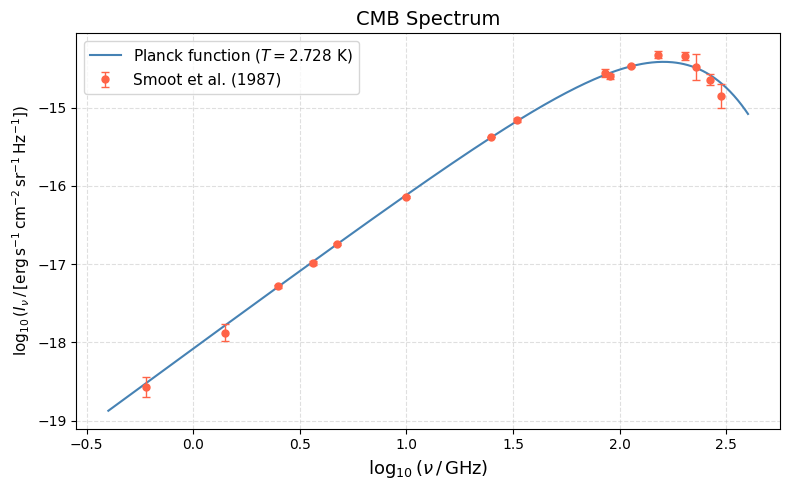

Figure saved as CMB_spectrum_loglog.png


In [8]:
# --- log-log プロット ---
fig, ax = plt.subplots(figsize=(8, 5))

# 黒体輻射フィット曲線
ax.plot(
    np.log10(nu_fit / 1e9),
    np.log10(B_nu),
    color="steelblue",
    lw=1.5,
    label=f"Planck function ($T={T_CMB}$ K)",
)

# 観測データ (非対称誤差バー)
# log スケールでの誤差伝播: δ(log I) = δI / (I * ln10)
log_err_up = df["err_up"] / (df["intensity"] * np.log(10))
log_err_dn = df["err_dn"] / (df["intensity"] * np.log(10))

ax.errorbar(
    np.log10(df["freq_GHz"]),
    np.log10(df["intensity"]),
    yerr=[log_err_dn, log_err_up],
    fmt="o",
    color="tomato",
    markersize=5,
    capsize=3,
    lw=1,
    label="Smoot et al. (1987)",
)

ax.set_xlabel(r"$\log_{10}(\nu\,/\,\mathrm{GHz})$", fontsize=13)
ax.set_ylabel(
    r"$\log_{10}(I_\nu\,/\,[\mathrm{erg\,s^{-1}\,cm^{-2}\,sr^{-1}\,Hz^{-1}}])$",
    fontsize=11,
)
ax.set_title("CMB Spectrum", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig("CMB_spectrum_loglog.png", dpi=150)
plt.show()
print("Figure saved as CMB_spectrum_loglog.png")